## Setup & Data Loading

We import the necessary libraries and load the five relevant tables from the Instacart dataset. The dataset also contains `order_products_train`, which holds each user's most recent order and is intended for purchase prediction models. Since our goal is to analyse purchasing patterns rather than build a predictive model, we only use `order_products_prior`, which contains the full order history across all users.

In [10]:
from pathlib import Path
from itertools import combinations
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

In [ ]:
# Locate the project root by walking up until pyproject.toml is found, so the
# notebook works regardless of the directory it is launched from.
def find_project_root(marker="pyproject.toml"):
    for directory in [Path.cwd(), *Path.cwd().parents]:
        if (directory / marker).exists():
            return directory
    raise FileNotFoundError(f"Could not locate the project root (no '{marker}' found).")


DATA_DIR = find_project_root() / "data"

# Visual identity - colours taken from the Streamlit dashboard so every
# project visualisation shares the same look.
BAR_COLOR = "#FB6A4A"     # accent colour used for the dashboard's bar charts
HEATMAP_CMAP = "YlOrRd"   # sequential colormap used by the dashboard heatmap

sns.set_theme(style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 110

# Load the five relevant tables from the Instacart dataset
orders = pd.read_csv(DATA_DIR / "orders.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
aisles = pd.read_csv(DATA_DIR / "aisles.csv")
departments = pd.read_csv(DATA_DIR / "departments.csv")
order_products = pd.read_csv(DATA_DIR / "order_products__prior.csv")

# First overview of the data
for name, df in [("orders", orders), ("products", products),
                 ("aisles", aisles), ("departments", departments),
                 ("order_products", order_products)]:
    print(f"\n{'=' * 40}")
    print(f"{name}: {df.shape}")
    print(df.head(3))
    print(df.isnull().sum())

print("\nUnique users:", orders["user_id"].nunique())


orders: (3421083, 7)
   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

products: (49688, 4)
   product_id                          product_name  aisle_id  department_id
0           1            Chocolate Sandwich Cookies        61             19
1           2                      All-Seasons Salt       104             13
2           3  Robust Golden Unsweetened Oolong Tea        9

The dataset consists of over 3.4 million orders from 206,209 users, covering 49,688 products organised across 134 aisles and 21 departments. The purchase history contains 32 million individual product entries.

The only missing values appear in `days_since_prior_order` in the orders table (206,209 entries). This number matches exactly the number of unique users, confirming that each user has one first order with no prior order to reference. These missing values are therefore expected and not treated as a data quality issue. All other tables are complete with no missing values.

## Data Preparation

The Instacart dataset is split across multiple tables. Products only contain numeric IDs for aisles and departments, not their names. We merge these tables to create a single product table with readable labels for all visualisations.

In [2]:
# Merge products, aisles and departments
products_full = products.merge(aisles, on="aisle_id").merge(departments, on="department_id")
print(products_full.head())

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id                       aisle department  
0             19               cookies cakes     snacks  
1             13           spices seasonings     pantry  
2              7                         tea  beverages  
3              1                frozen meals     frozen  
4             13  marinades meat preparation     pantry  


## Most Purchased Products

We start by identifying the most frequently purchased products across all orders. This gives us a first overview of customer preferences and helps identify key products that should be prominently placed in the store.

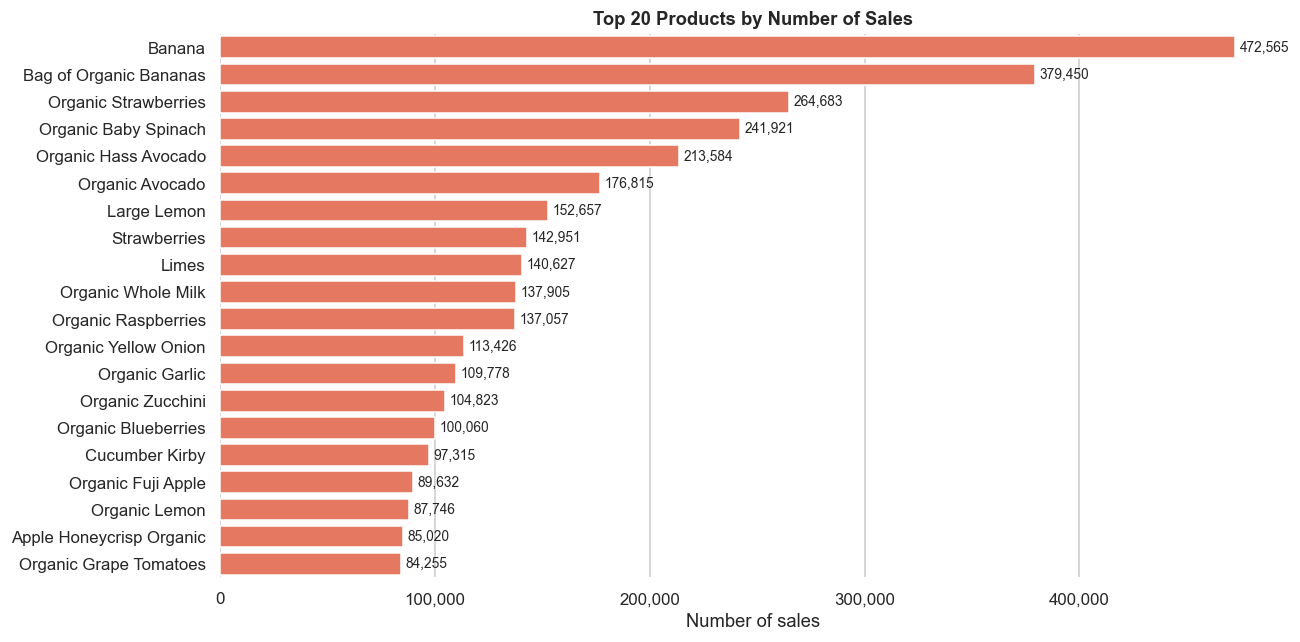

In [3]:
top_products = (order_products.groupby("product_id")["product_id"]
                .count()
                .reset_index(name="count")
                .merge(products[["product_id", "product_name"]], on="product_id")
                .sort_values("count", ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_products, x="count", y="product_name", color=BAR_COLOR, ax=ax)
ax.set_title("Top 20 Products by Number of Sales")
ax.set_xlabel("Number of sales")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3, fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Bananas are by far the most purchased product, followed by Bag of Organic Bananas and Organic Strawberries. The top 20 is dominated by fresh fruit and vegetables, with a notable preference for organic products.

This suggests that customers on Instacart tend to prioritise fresh and healthy produce. For store layout optimisation, this implies that the fresh produce section should be easily accessible and prominently placed, as it drives a large share of purchases.

## Sales by Department

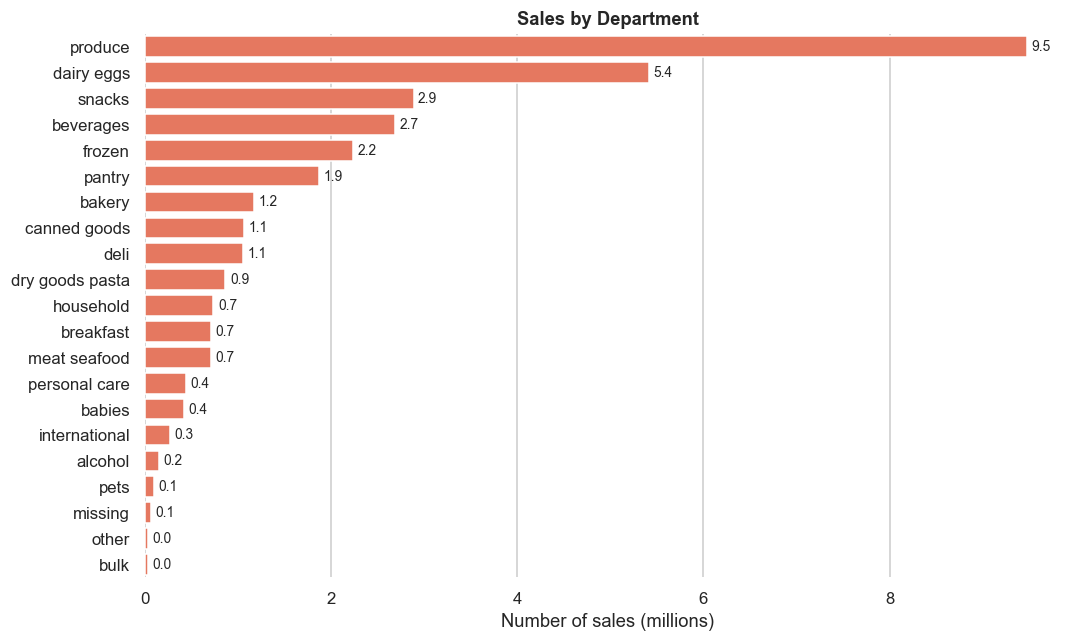

In [4]:
dept_counts = (order_products.merge(products_full, on="product_id")
               .groupby("department")["product_id"]
               .count()
               .reset_index(name="count")
               .sort_values("count", ascending=False))

# Scale to millions so the axis is readable (the label now matches the values).
dept_counts["count_millions"] = dept_counts["count"] / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=dept_counts, x="count_millions", y="department", color=BAR_COLOR, ax=ax)
ax.set_title("Sales by Department")
ax.set_xlabel("Number of sales (millions)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Produce (Packaged Vegetables and Fruits, Fresh Vegetables, Fresh Fruits, Fresh Herbs and Packaged Produce) is by far the most purchased department with around 9 million purchases, followed by dairy & eggs with around 5 million. This confirms the pattern seen in the top products chart: fresh goods dominate customer purchases. Snacks and beverages rank third and fourth, while departments like bulk, other and alcohol are rarely purchased on this platform.

For store layout, this suggests that produce and dairy should be the most accessible and central departments.

## Orders by Day of Week and Hour

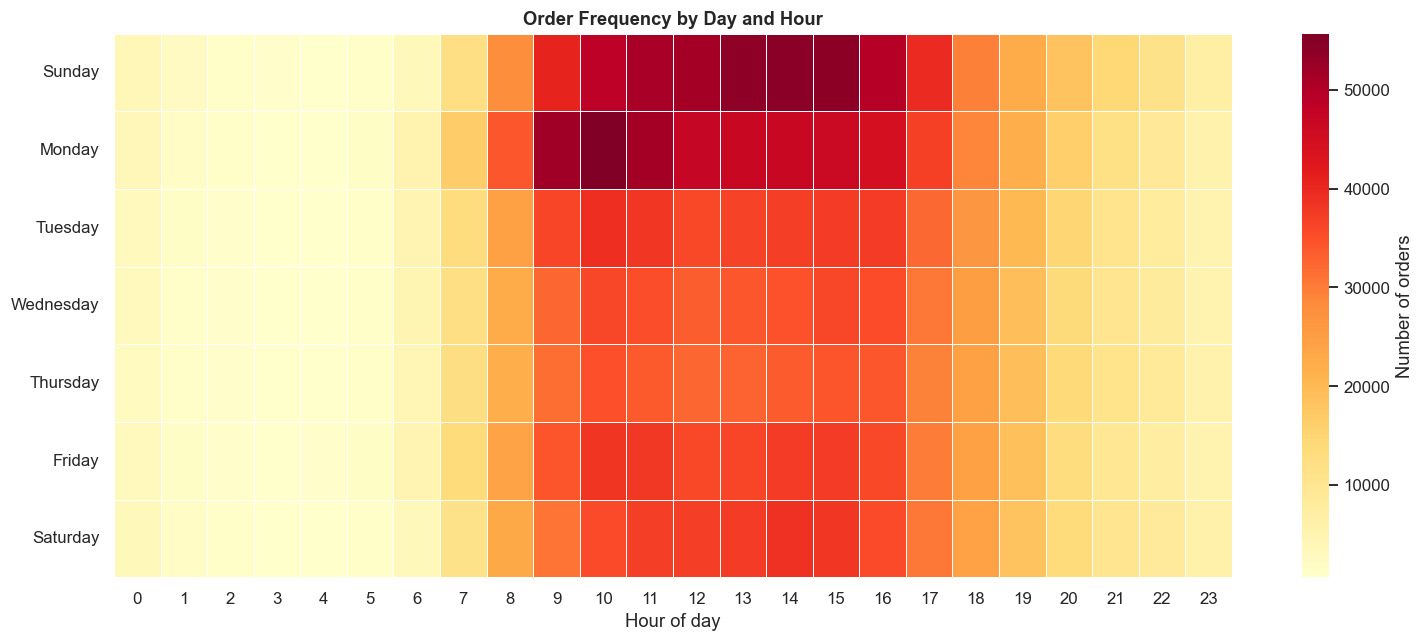

In [5]:
# Orders by day of week and hour of day
heatmap_data = (orders.groupby(["order_dow", "order_hour_of_day"])["order_id"]
                .count()
                .unstack())

# Rename days for readability
heatmap_data.index = ["Sunday", "Monday", "Tuesday", "Wednesday",
                      "Thursday", "Friday", "Saturday"]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap=HEATMAP_CMAP, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Number of orders"}, ax=ax)
ax.set_title("Order Frequency by Day and Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Most orders are placed on Sundays and Mondays between 9 and 15 hours. This pattern likely reflects common shopping behaviour: customers plan their weekly groceries at the start of the week. Activity is low before 6am and after 10pm across all days.

For an online grocery store, this suggests that promotional campaigns and personalised recommendations should be prioritised on Sunday and Monday mornings to reach customers when they are most likely to be placing orders.

## Top 20 Products by Reorder Rate

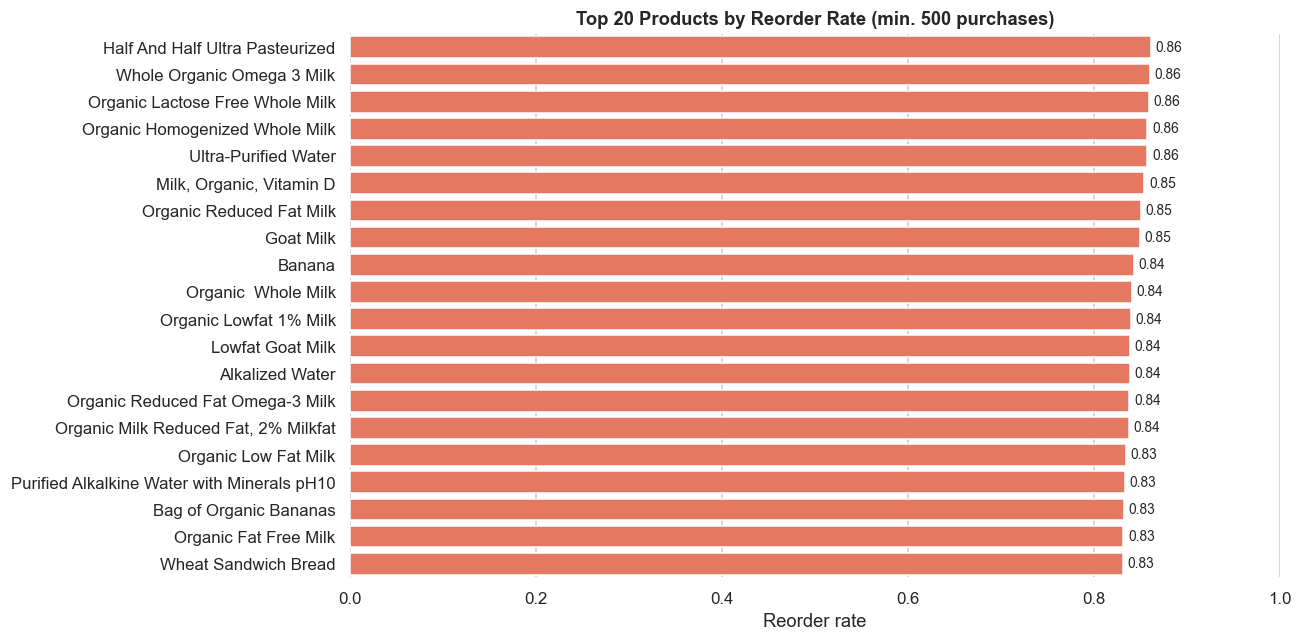

In [6]:
# Reorder rate per product
reorder_rate = (order_products.groupby("product_id")["reordered"]
                .mean()
                .reset_index()
                .rename(columns={"reordered": "reorder_rate"}))

# Merge with product names
reorder_rate = reorder_rate.merge(products[["product_id", "product_name"]],
                                  on="product_id")

# Only products with at least 500 purchases, so the ranking is not driven by
# rare products with very few orders.
product_counts = order_products.groupby("product_id")["product_id"].count()
popular_products = product_counts[product_counts >= 500].index

reorder_rate_filtered = reorder_rate[reorder_rate["product_id"].isin(popular_products)]
top_reorder = reorder_rate_filtered.sort_values("reorder_rate", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_reorder, x="reorder_rate", y="product_name", color=BAR_COLOR, ax=ax)
ax.set_title("Top 20 Products by Reorder Rate (min. 500 purchases)")
ax.set_xlabel("Reorder rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Products with a reorder rate above 0.8 are almost exclusively everyday staples such as milk, water and bananas. This means that over 80% of purchases of these products are repeat orders from returning customers.

This is a strong signal for customer loyalty at the product level. For an online grocery store, these products are ideal candidates for subscription models or automatic reorder reminders, as customers buy them repeatedly and predictably.

## Reorder Loyalty Beyond the Bestsellers

The reorder ranking above is deliberately restricted to popular products and is dominated by everyday staples. Strong customer loyalty, however, is not exclusive to bestsellers. To find where else habitual repeat-buying occurs, we plot every product's reorder rate against its total purchase volume and separate the five highest-volume departments from the rest of the assortment. The dashed line marks the overall reorder rate across the platform.

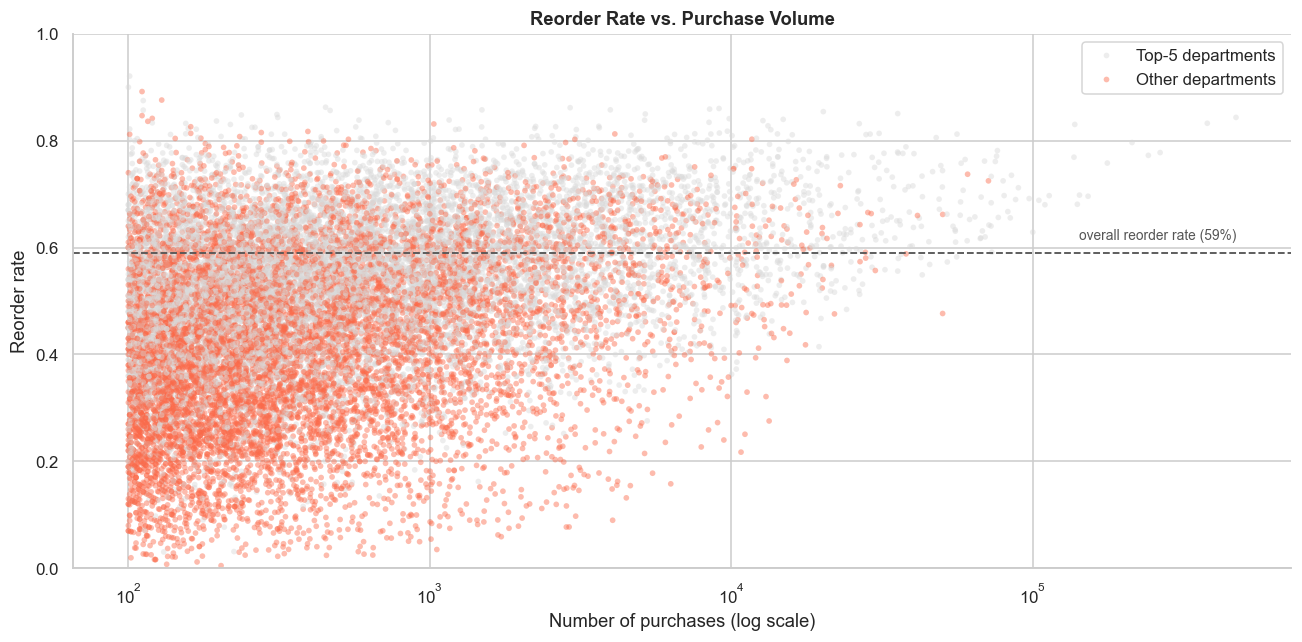

In [7]:
# Reorder rate and purchase volume per product
overall_reorder_rate = order_products["reordered"].mean()

product_stats = (order_products.groupby("product_id")
                 .agg(count=("product_id", "size"),
                      reorder_rate=("reordered", "mean"))
                 .reset_index()
                 .merge(products_full[["product_id", "product_name",
                                       "department", "aisle"]],
                        on="product_id"))

# The five highest-volume departments — the "bestseller" categories
top5_departments = (product_stats.groupby("department")["count"].sum()
                    .sort_values(ascending=False)
                    .head(5).index.tolist())
product_stats["segment"] = product_stats["department"].isin(top5_departments).map(
    {True: "Top-5 departments", False: "Other departments"})

# Plot reorder rate against purchase volume (products with at least 100 sales)
plot_df = product_stats[product_stats["count"] >= 100]

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=plot_df, x="count", y="reorder_rate", hue="segment",
                palette={"Top-5 departments": "#D9D9D9",
                         "Other departments": BAR_COLOR},
                s=14, alpha=0.45, edgecolor="none", ax=ax)
ax.set_xscale("log")
ax.axhline(overall_reorder_rate, color="#555555", linestyle="--", linewidth=1.2)
ax.text(plot_df["count"].max(), overall_reorder_rate + 0.02,
        f"overall reorder rate ({overall_reorder_rate:.0%})",
        ha="right", va="bottom", fontsize=9, color="#555555")
ax.set_title("Reorder Rate vs. Purchase Volume")
ax.set_xlabel("Number of purchases (log scale)")
ax.set_ylabel("Reorder rate")
ax.set_ylim(0, 1)
ax.legend(title="")
sns.despine()
plt.tight_layout()
plt.show()

Even outside the five largest departments, produce, dairy & eggs, snacks, beverages and frozen, many products reach reorder rates well above the platform average of roughly 59%. Among the 4,525 such products that sell between 300 and 3,000 times, 844 beat the overall reorder rate. These are niche items with small but devoted customer bases: artisan breads, specialty wines, granola and premium deli meats.

This long-tail loyalty is the analytical basis for the dashboard's **Hidden Gems** view, which isolates exactly these products, outside the top departments, inside a chosen volume range, with high reorder rates, as candidates for targeted promotions, category newsletters and subscription offers.

## Purchasing Patterns Across Categories

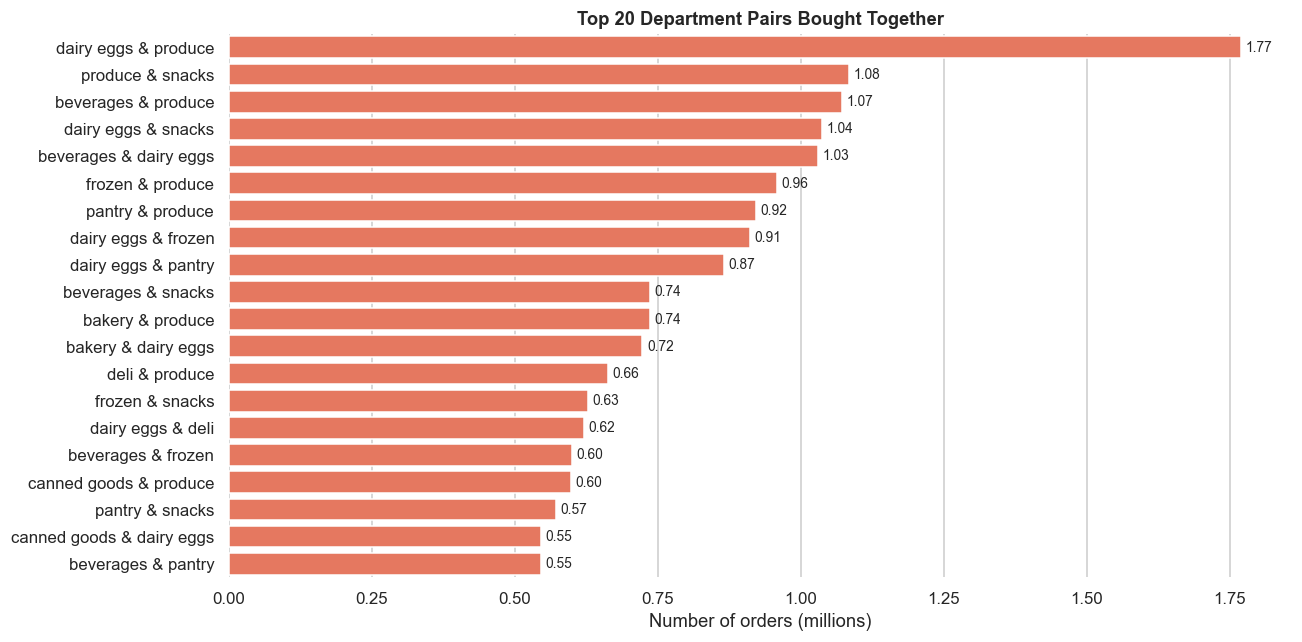

In [8]:
# Merge order_products with product and department info
order_dept = (order_products
              .merge(products[["product_id", "department_id"]], on="product_id")
              .merge(departments, on="department_id"))

# Count how often each pair of departments appears in the same order
dept_pairs = (order_dept.groupby("order_id")["department"]
              .apply(list)
              .reset_index())

pair_counts = Counter()
for depts in dept_pairs["department"]:
    for pair in combinations(sorted(set(depts)), 2):
        pair_counts[pair] += 1

# Keep the 20 most frequent department pairs
pairs_df = pd.DataFrame(pair_counts.items(), columns=["pair", "count"])
pairs_df[["dept_1", "dept_2"]] = pd.DataFrame(pairs_df["pair"].tolist(),
                                              index=pairs_df.index)
pairs_df = (pairs_df.drop(columns="pair")
            .sort_values("count", ascending=False)
            .head(20))

# Scale to millions so the axis label matches the plotted values.
pairs_df["count_millions"] = pairs_df["count"] / 1_000_000
pairs_df["pair_label"] = pairs_df["dept_1"] + " & " + pairs_df["dept_2"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=pairs_df, x="count_millions", y="pair_label", color=BAR_COLOR, ax=ax)
ax.set_title("Top 20 Department Pairs Bought Together")
ax.set_xlabel("Number of orders (millions)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

To analyse whether there are typical purchasing patterns across product categories, we visualised which departments are most commonly bought together. The by far most frequently co-purchased department pair is "dairy eggs & produce", appearing together in approximately 1.8 million orders. The next pairs are "produce & snacks" and "beverages & produce", each with slightly over 1 million orders.

Produce appears in almost every top pair, confirming its importance in grocery shopping behaviour. Dairy and eggs are equally dominant. The pattern shows that customers almost always buy from these departments and combine them with others.

## Co-Purchase at Aisle Level

The department view above is too coarse for product placement decisions. With only 21 departments, produce or dairy & eggs appears in almost every top pair simply because customers buy from them on nearly every visit, the pairs are dominated by department size rather than by genuine association.

To obtain an actionable signal we refine the analysis to the 134 **aisles** and replace raw co-occurrence counts with **lift**. Lift measures how much more often two aisles are bought together than their individual popularity would predict: a value of 1.0 means the two aisles are statistically independent, while a value of 3.0 means the pair occurs three times more often than chance. Unlike raw counts, which simply rank the largest aisles together, lift rewards real association. The product level, with 49,688 products, is too sparse to give a stable pairwise signal, which is why the aisle is the granularity used by the final dashboard.

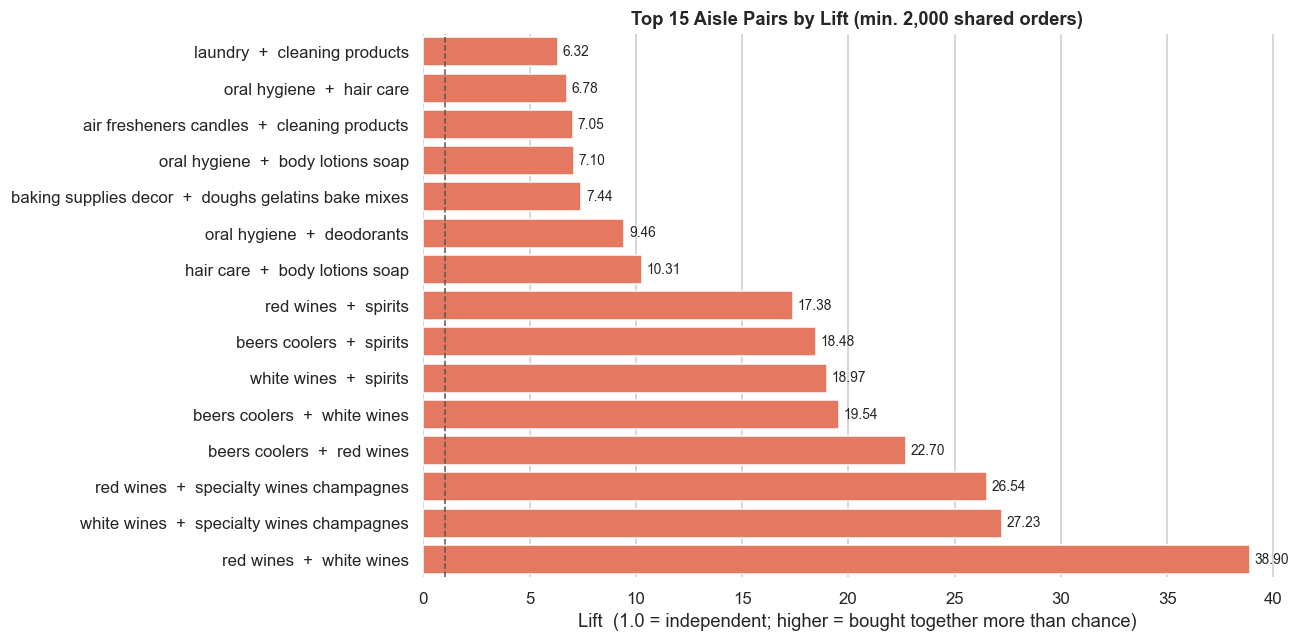

In [ ]:
# One row per (order, aisle): which aisles each order touches
order_aisle = (order_products[["order_id", "product_id"]]
               .merge(products[["product_id", "aisle_id"]], on="product_id")
               .drop_duplicates(["order_id", "aisle_id"]))

# Encode orders and aisles as contiguous integer codes for an incidence matrix
order_codes = order_aisle["order_id"].astype("category").cat.codes.to_numpy()
aisle_cat = order_aisle["aisle_id"].astype("category")
aisle_codes = aisle_cat.cat.codes.to_numpy()
aisle_id_by_code = list(aisle_cat.cat.categories)
n_orders = int(order_codes.max()) + 1
n_aisles = len(aisle_id_by_code)
del order_aisle

# Orders x aisles incidence matrix; co-occurrence = incidence.T @ incidence.
# The matrix is large but transient, so it is released right after the product.
incidence = np.zeros((n_orders, n_aisles), dtype=np.float32)
incidence[order_codes, aisle_codes] = 1.0
del order_codes, aisle_codes
cooccurrence = (incidence.T @ incidence).astype(np.float64)
del incidence

# Lift = P(A and B) / (P(A) * P(B)) — how far a pair beats independence
aisle_order_count = np.diag(cooccurrence).copy()
prob = aisle_order_count / n_orders
expected = np.outer(prob, prob) * n_orders
with np.errstate(divide="ignore", invalid="ignore"):
    lift = cooccurrence / expected

# Flatten the upper triangle into a tidy table of aisle pairs
i_idx, j_idx = np.triu_indices(n_aisles, k=1)
aisle_pairs = pd.DataFrame({
    "aisle_id_1": [aisle_id_by_code[i] for i in i_idx],
    "aisle_id_2": [aisle_id_by_code[j] for j in j_idx],
    "co_orders": cooccurrence[i_idx, j_idx].astype("int64"),
    "lift": lift[i_idx, j_idx],
})
aisle_name = aisles.set_index("aisle_id")["aisle"]
aisle_pairs["aisle_1"] = aisle_pairs["aisle_id_1"].map(aisle_name)
aisle_pairs["aisle_2"] = aisle_pairs["aisle_id_2"].map(aisle_name)

# Keep only pairs with enough shared orders, then rank by lift
MIN_SHARED_ORDERS = 2000
top_pairs = (aisle_pairs[aisle_pairs["co_orders"] >= MIN_SHARED_ORDERS]
             .sort_values("lift", ascending=False)
             .head(15)
             .copy())
top_pairs["pair_label"] = top_pairs["aisle_1"] + "  +  " + top_pairs["aisle_2"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_pairs.sort_values("lift"), x="lift", y="pair_label",
            color=BAR_COLOR, ax=ax)
ax.axvline(1.0, color="#555555", linestyle="--", linewidth=1)
ax.set_title(f"Top 15 Aisle Pairs by Lift (min. {MIN_SHARED_ORDERS:,} shared orders)")
ax.set_xlabel("Lift  (1.0 = independent; higher = bought together more than chance)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3, fontsize=9)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Ranked by lift, the strongest aisle pairs are highly specific and immediately actionable. Wine aisles dominate the top of the ranking, *red wines* and *white wines* are bought together almost 39 times more often than chance would predict, followed by further alcohol combinations involving *beers & coolers*, *spirits* and *specialty wines & champagnes*. Below the alcohol cluster three clear themes emerge: personal care (*oral hygiene*, *deodorants*, *hair care*, *body lotions & soap*), baking (*baking supplies* with *doughs & bake mixes*) and household cleaning (*laundry* paired with *cleaning products*, sharing almost 14,000 orders).

None of these relationships would surface from raw counts or from the department view, where every pair simply includes produce. This aisle-level lift analysis is the analytical foundation of the dashboard's **Aisles Bought Together** page, its ranked co-purchase table, its lift metric and the co-purchase network whose clusters correspond to exactly the shopping-basket themes seen here.

## Summary & Conclusions

#### Product popularity
Fresh produce dominates the platform. Bananas, organic strawberries and avocados are the most purchased products, and 13 out of the top 20 products carry an organic label. This reflects a clear customer preference for fresh and healthy groceries.

#### Department-level patterns
Produce and dairy & eggs are the two anchor departments, accounting for the vast majority of all purchases. Together they form the most common department pair, appearing in nearly 1.8 million orders simultaneously. Every major department pair in the top 20 includes either produce or dairy & eggs.

#### Reorder behaviour
The products with the highest reorder rates are everyday staples, primarily milk variants, water and bananas. Reorder rates above 80% indicate very strong habitual buying behaviour for these items.

#### Ordering time patterns
Customers are most active on Sundays and Mondays between 9 and 15 hours. This suggests that weekly grocery planning happens at the start of the week.


#### Aisle-level co-purchase
Measured by lift rather than raw frequency, the strongest co-purchase relationships are concentrated within clear themes, wines, personal care, baking and household cleaning — rather than around the high-volume departments. These tightly associated aisles are natural candidates for adjacent shelf placement and cross-selling, and form the basis of the dashboard's co-purchase network.

#### Loyalty in the long tail
Habitual repeat-buying is not limited to bestsellers. Hundreds of niche products outside the largest departments, artisan breads, specialty wines, premium deli meats, reach reorder rates above the platform average of roughly 59%, marking them as small but loyal-customer categories worth targeted promotion.
